# Genetic Algorithm with Elitism

## 1. Objective

This notebook implements a modified genetic algorithm with elitism from scratch for three minimization problems. The implementation includes binary encoding, real-number encoding, an automatic stagnation-based stopping criterion, repeated experiments, convergence plots, derivative-method comparisons, and an elitism analysis.

## 2. Description

The assignment requires testing a genetic algorithm on Test Problem 1, Ackley with n=2, and Rastrigin with n=5. For each problem, both binary and real encodings are evaluated with 20 independent runs. The reusable implementation is placed in `src/`; this notebook coordinates the experiments and saves the outputs in `outputs/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.benchmark_functions import get_benchmark_problems, problem_table
from src.experiments import (
    CONVERGENCE_FILENAMES,
    PLOT_PROBLEM_ORDER,
    binary_encoding_table,
    build_derivative_comparison,
    build_results_summary,
    ensure_output_dirs,
    run_elitism_benefit_experiment,
    run_independent_experiments,
    run_pilot_experiments,
    save_table,
    select_generation_counts,
    select_median_representative_runs,
    validate_outputs,
)
from src.plotting import plot_convergence, plot_elitism_median
from src.stopping import StagnationConfig

pd.set_option("display.precision", 10)
pd.set_option("display.max_columns", 20)

OUTPUT_DIR = Path("outputs")
paths = ensure_output_dirs(OUTPUT_DIR)
problems = get_benchmark_problems()

## 3. Genetic Algorithm with elitism

The GA is implemented from scratch in `src/binary_ga.py` and `src/real_ga.py`. In each generation, the best `elite_size=1` individual is copied unchanged to the next population. For minimization, this preserves the best individual found so far, so the elitist best-fitness history is non-increasing.

Shared default parameters are `population_size=100`, `Pc=0.9`, and `elite_size=1`.

In [2]:
pd.DataFrame(
    [
        {"Parameter": "Population size", "Value": 100},
        {"Parameter": "Crossover probability Pc", "Value": 0.9},
        {"Parameter": "Elite size", "Value": 1},
        {"Parameter": "SBX distribution index eta_c", "Value": 20},
        {"Parameter": "Polynomial mutation index eta_m", "Value": 20},
    ]
)

,Parameter,Value
0,Population size,100.0
1,Crossover probability Pc,0.9
2,Elite size,1.0
3,SBX distribution index eta_c,20.0
4,Polynomial mutation index eta_m,20.0


## 4. Automatic stopping criterion

Possible stopping criteria include a maximum number of generations, a target fitness threshold, a population diversity threshold, a maximum number of function evaluations, and stagnation of the best fitness.

This project uses stagnation of the best fitness because it is problem independent and directly reflects the observed convergence behavior. A run stops when the best fitness has not improved by at least `tol` for `patience` consecutive generations after `min_generations`.

To reconcile the requirement to estimate generations from convergence plots, the workflow is:

1. Run pilot experiments with the automatic stopping criterion.
2. Select one fixed generation count per problem from the pilot stopped generations.
3. Use that fixed generation count for the 20 independent runs of both encodings.

In [3]:
stopping_config = StagnationConfig(
    min_generations=100,
    max_generations=1000,
    patience=50,
    tol=1e-8,
)
stopping_config

StagnationConfig(min_generations=100, max_generations=1000, patience=50, tol=1e-08)

## 5. Benchmark functions

All benchmark functions are implemented for minimization in `src/benchmark_functions.py`. The known global optimum value is 0 for all three problems.

In [4]:
pd.DataFrame(problem_table())

,Problem,Dimension,Lower bound,Upper bound,Known optimum f(x*)
0,Test Problem 1,2,-2.048,2.048,0.0
1,"Ackley function, n=2",2,-32.768,32.768,0.0
2,"Rastrigin function, n=5",5,-5.120,5.120,0.0


## 6. Binary encoding GA implementation

The binary GA uses random initialization, single-point crossover, bit-flip mutation, and roulette wheel selection. For minimization, roulette selection uses a positive transformed score based on inverse shifted fitness. Six digits of precision are used to compute each variable's bit length.

In [5]:
binary_encoding_table()

,Problem,Bits per variable,Chromosome length,Binary mutation probability
0,Test Problem 1,"[22, 22]",44,0.0227272727
1,"Ackley function, n=2","[26, 26]",52,0.0192307692
2,"Rastrigin function, n=5","[24, 24, 24, 24, 24]",120,0.0083333333


## 7. Real encoding GA implementation

The real GA uses uniform random initialization, deterministic binary tournament selection, simulated binary crossover (SBX), and polynomial mutation. SBX and polynomial mutation are implemented directly in `src/real_ga.py`, and all offspring are clipped to the problem bounds.

In [6]:
pd.DataFrame(
    [
        {"Component": "Selection", "Real encoding implementation": "Binary deterministic tournament"},
        {"Component": "Crossover", "Real encoding implementation": "Simulated Binary Crossover, eta_c=20"},
        {"Component": "Mutation", "Real encoding implementation": "Polynomial mutation, eta_m=20"},
        {"Component": "Mutation probability", "Real encoding implementation": "1 / dimension"},
        {"Component": "Bounds", "Real encoding implementation": "np.clip after crossover and mutation"},
    ]
)

,Component,Real encoding implementation
0,Selection,Binary deterministic tournament
1,Crossover,"Simulated Binary Crossover, eta_c=20"
2,Mutation,"Polynomial mutation, eta_m=20"
3,Mutation probability,1 / dimension
4,Bounds,np.clip after crossover and mutation


## 8. Pilot runs and generation selection

The following pilot runs use the automatic stopping criterion. The selected fixed generation count for each problem is the maximum pilot stopped generation plus a 25-generation buffer, rounded up to the next multiple of 25 and capped by the automatic stopping maximum.

In [7]:
pilot_results, pilot_histories = run_pilot_experiments(
    pilot_runs_per_case=3,
    stopping_config=stopping_config,
)
generation_counts, generation_selection = select_generation_counts(
    pilot_results,
    stopping_config=stopping_config,
)

pilot_results.to_csv(paths["tables"] / "pilot_runs.csv", index=False)
save_table(
    generation_selection,
    paths["tables"] / "generation_selection.csv",
    paths["tables"] / "generation_selection.tex",
)
generation_selection

,Problem,Max pilot stopped generation,Selected fixed generations,Selection rule
0,Test Problem 1,186,225,ceil((max pilot stop + 25) / 25) * 25
1,"Ackley function, n=2",345,375,ceil((max pilot stop + 25) / 25) * 25
2,"Rastrigin function, n=5",412,450,ceil((max pilot stop + 25) / 25) * 25


## 9. Twenty independent runs

The 20 independent runs use fixed generation counts selected from the pilot stage. Seeds are reproducible and different across problem, encoding, and run index.

In [8]:
results, histories = run_independent_experiments(
    generation_counts=generation_counts,
    runs_per_case=20,
)
results.to_csv(paths["tables"] / "all_runs_long.csv", index=False)
results.groupby(["problem", "encoding"]).agg(
    runs=("run", "count"),
    mean_final_fitness=("final_best_fitness", "mean"),
    min_final_fitness=("final_best_fitness", "min"),
    max_final_fitness=("final_best_fitness", "max"),
)

runs  mean_final_fitness  min_final_fitness  \
problem                 encoding                                                
Ackley function, n=2    binary      20        0.0000019531   1.9531377053e-06   
                        real        20        0.0027469057   6.4899824918e-04   
Rastrigin function, n=5 binary      20        4.6273971284   9.2377661076e-11   
                        real        20        0.0032384630   3.5408863756e-04   
Test Problem 1          binary      20        0.1238312633   6.7712049165e-12   
                        real        20        0.0003893459   7.1510937553e-06   

                                  max_final_fitness  
problem                 encoding                     
Ackley function, n=2    binary         0.0000019531  
                        real           0.0060463732  
Rastrigin function, n=5 binary        11.0824482683  
                        real           0.0294330701  
Test Problem 1          binary         1.0000009766  
                        real           0.0040858215

## 10. Results table

The required summary table reports the final best fitness value from each independent run, followed by mean, sample standard deviation, minimum, and maximum for each problem and encoding.

In [9]:
results_summary = build_results_summary(results, runs_per_case=20)
save_table(
    results_summary,
    paths["tables"] / "results_summary.csv",
    paths["tables"] / "results_summary.tex",
)
results_summary

,Experiment,Binary encoding - Test problem 1,Real encoding - Test problem 1,"Binary encoding - Ackley function, n=2","Real encoding - Ackley function, n=2","Binary encoding - Rastrigin function, n=5","Real encoding - Rastrigin function, n=5"
0,Experiment 1,1.7017825150e-05,0.0001024660,1.9531377196e-06,0.0008545734,1.0841635884e+01,0.0057507726
1,Experiment 2,2.4173278849e-01,0.0000547345,1.9531377338e-06,0.0046861943,6.1591100278e+00,0.0016538985
2,Experiment 3,2.4173277421e-01,0.0001767979,1.9531377196e-06,0.0019016997,1.1082448268e+01,0.0010703557
3,Experiment 4,1.6644183851e-04,0.0000339621,1.9531377196e-06,0.0006489982,9.9495905857e-01,0.0019475938
4,Experiment 5,2.4173278849e-01,0.0001458867,1.9531377196e-06,0.0044896891,4.7022747637e+00,0.0009907991
5,Experiment 6,1.5376069364e-02,0.0040858215,1.9531377196e-06,0.0008725722,2.7873167934e+00,0.0023182201
6,Experiment 7,1.0816057143e-02,0.0000736468,1.9531377338e-06,0.0020425882,6.1591100278e+00,0.0077743746
7,Experiment 8,4.0000119143e-02,0.0000276937,1.9531377196e-06,0.0020982567,2.2357725168e+00,0.0005559836
8,Experiment 9,6.4355731518e-05,0.0001616059,1.9531377196e-06,0.0037355166,2.2357725168e+00,0.0021210665
9,Experiment 10,3.4754960798e-02,0.0008489944,1.9531377338e-06,0.0009841946,9.2377661076e-11,0.0017208026


## 11. Convergence plots

For each problem and encoding, the representative convergence curve is the run whose final best fitness is closest to the median final best fitness. This avoids choosing an unusually lucky or unlucky run.

In [10]:
representative_runs = select_median_representative_runs(results)
save_table(
    representative_runs,
    paths["tables"] / "representative_runs.csv",
    paths["tables"] / "representative_runs.tex",
)
representative_runs

,Problem,problem_key,encoding,Selected run,Final best fitness,Selection rule
0,Test Problem 1,test_problem_1,binary,8,0.0400001191,Run closest to median final best fitness withi...
1,Test Problem 1,test_problem_1,real,1,0.0001024660,Run closest to median final best fitness withi...
2,"Rastrigin function, n=5",rastrigin_n5,binary,5,4.7022747637,Run closest to median final best fitness withi...
3,"Rastrigin function, n=5",rastrigin_n5,real,12,0.0011416027,Run closest to median final best fitness withi...
4,"Ackley function, n=2",ackley_n2,binary,1,0.0000019531,Run closest to median final best fitness withi...
5,"Ackley function, n=2",ackley_n2,real,16,0.0022386613,Run closest to median final best fitness withi...


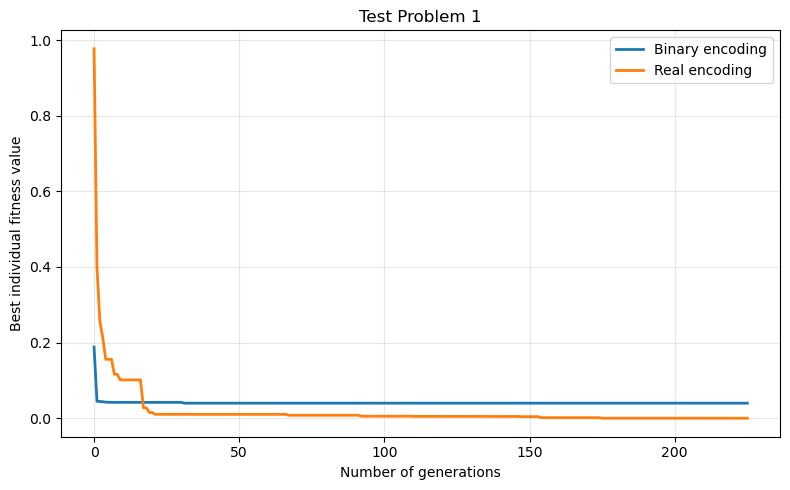

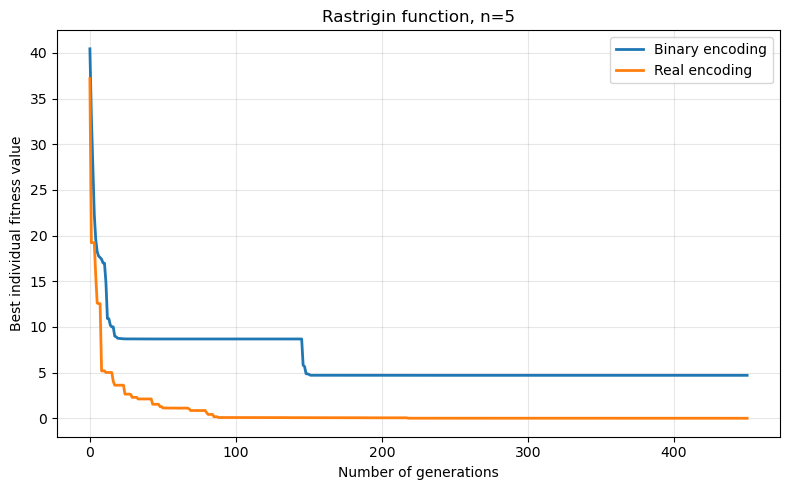

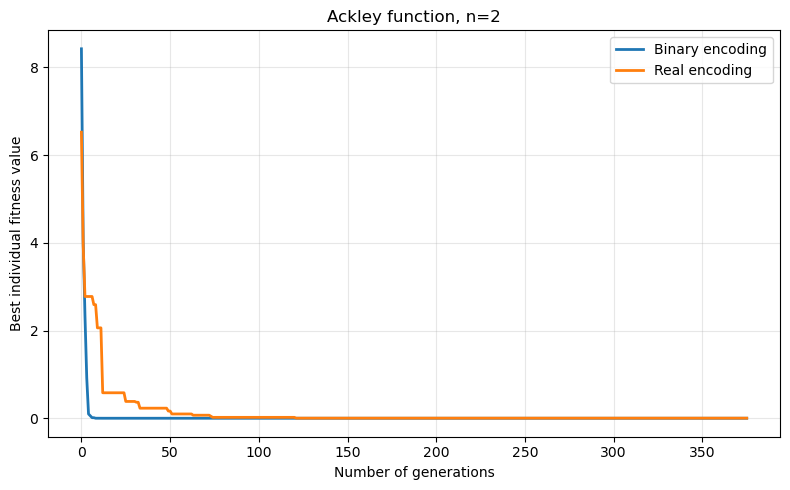

In [11]:
for problem_key in PLOT_PROBLEM_ORDER:
    problem = problems[problem_key]
    selected = representative_runs[representative_runs["problem_key"] == problem_key]
    binary_run = int(selected[selected["encoding"] == "binary"]["Selected run"].iloc[0])
    real_run = int(selected[selected["encoding"] == "real"]["Selected run"].iloc[0])
    fig, ax = plot_convergence(
        problem.name,
        histories[(problem_key, "binary", binary_run)],
        histories[(problem_key, "real", real_run)],
        paths["figures"] / CONVERGENCE_FILENAMES[problem_key],
    )
    plt.show()

## 12. Comparison with derivative-based method

BFGS is a derivative-based quasi-Newton method. It can be very efficient on smooth problems when initialized in a good basin of attraction. GAs can be useful on multimodal problems such as Rastrigin and Ackley because they sample many points and are less dependent on local gradient information or a single starting point. A GA is not necessarily better than a derivative-based method when the objective is smooth, cheap to evaluate, and a good initial point is available.

In [12]:
derivative_comparison = build_derivative_comparison(results)
save_table(
    derivative_comparison,
    paths["tables"] / "derivative_comparison.csv",
    paths["tables"] / "derivative_comparison.tex",
)
derivative_comparison

,Problem,Method,Best fitness,Best solution,Success,Iterations / evaluations
0,Test Problem 1,GA Binary with elitism,6.7712049165e-12,"[1.0000007, 1.0000017]",Not applicable,22600 evaluations
1,Test Problem 1,GA Real with elitism,7.1510937553e-06,"[0.99807932, 0.99634841]",Not applicable,22600 evaluations
2,Test Problem 1,BFGS (multi-start),1.9987382722e-11,"[0.99999553, 0.99999105]",True,22 iterations / 93 evaluations
3,"Ackley function, n=2",GA Binary with elitism,1.9531377053e-06,"[-4.8828125e-07, -4.8828125e-07]",Not applicable,37600 evaluations
4,"Ackley function, n=2",GA Real with elitism,6.4899824918e-04,"[-6.2059366e-06, 0.00022887787]",Not applicable,37600 evaluations
5,"Ackley function, n=2",BFGS (multi-start),4.4408920985e-16,"[0, 0]",False,0 iterations / 165 evaluations


## 13. Effect of elitism

The elitism benefit experiment uses real encoding on Rastrigin n=5. Rastrigin is multimodal, so preserving the best individual can visibly affect convergence. With elitism, the best-fitness curve is expected to be non-increasing for minimization. Without elitism, good individuals can be lost through crossover and mutation, so the generation-best curve may fluctuate or converge more slowly.

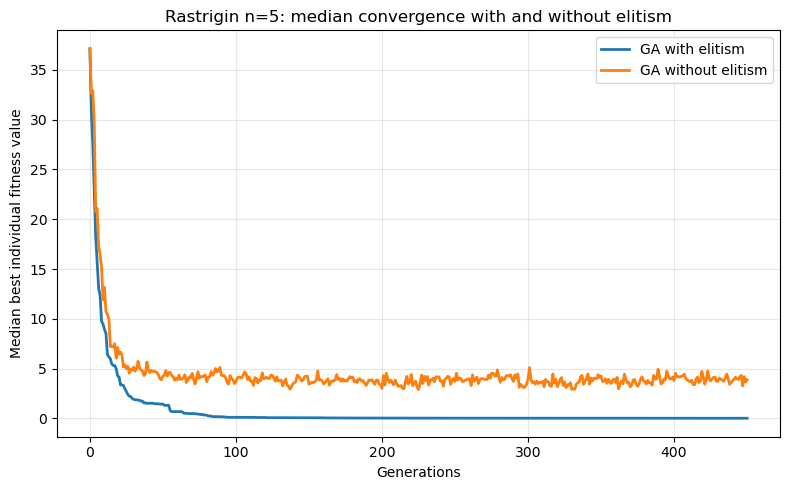

,runs,median_final_fitness,mean_final_fitness,min_final_fitness
phase,,,,
GA with elitism,20,0.0021549181,0.0024899360,0.0001065219
GA without elitism,20,0.4937656685,0.5381056424,0.1448206590


In [13]:
elitism_results, elitism_median, elitism_histories = run_elitism_benefit_experiment(
    generation_count=generation_counts["rastrigin_n5"],
    runs=20,
    problem_key="rastrigin_n5",
    encoding="real",
)
elitism_results.to_csv(paths["tables"] / "elitism_runs_long.csv", index=False)
elitism_median.to_csv(paths["tables"] / "elitism_median_history.csv", index=False)

fig, ax = plot_elitism_median(
    elitism_median,
    paths["figures"] / "elitism_vs_no_elitism_median.png",
)
plt.show()

elitism_results.groupby("phase").agg(
    runs=("run", "count"),
    median_final_fitness=("final_best_fitness", "median"),
    mean_final_fitness=("final_best_fitness", "mean"),
    min_final_fitness=("final_best_fitness", "min"),
)

## 14. Hybrid GA discussion

Derivative-based methods can be combined with a GA by using the GA as a global search phase and then applying gradient descent, Newton, or BFGS as a local refinement phase. The local search can be applied to the best individuals after GA convergence or periodically during evolution. This produces a hybrid GA, also called a memetic algorithm. In exploration-exploitation terms, the GA provides exploration across the search space, while derivative-based local search provides exploitation near promising solutions.

## 15. Conclusions

The project implements both required encodings from scratch, uses stagnation-based pilot runs to select fixed generation counts, performs the required 120 main GA runs, compares GA results with BFGS for Test Problem 1 and Ackley n=2, and evaluates elitism on Rastrigin n=5.

In [14]:
validation = validate_outputs(OUTPUT_DIR)
validation

,Check,Status
0,outputs/tables/results_summary.csv,OK
1,outputs/tables/results_summary.tex,OK
2,outputs/tables/derivative_comparison.csv,OK
3,outputs/tables/derivative_comparison.tex,OK
4,outputs/figures/convergence_test_problem_1.png,OK
5,outputs/figures/convergence_rastrigin_n5.png,OK
6,outputs/figures/convergence_ackley_n2.png,OK
7,outputs/figures/elitism_vs_no_elitism_median.png,OK
8,results_summary.csv has 20 experiments plus 4 ...,OK
9,derivative comparison includes Test Problem 1 ...,OK
